# 🛒 Notebook 05 — Cập nhật Shopee Recommender Model

**Mục tiêu:**
- Gộp dữ liệu từ Shopee (`data.xlsx` & `shopee_product_desc.json`) để xây dựng một tập catalog mới với hơn 15.000 sản phẩm.
- Huấn luyện lại mô hình Recommender (Content-based Filtering) sử dụng cấu trúc TF-IDF và Cosine Similarity.
- Xuất mô hình mới để tích hợp vào API backend, giúp chatbot AI tư vấn sâu hơn dựa trên `description`.

**Đầu vào:** `datas/recommend_dataset/data.xlsx`, `datas/recommend_dataset/shopee_product_desc.json`  
**Đầu ra:** `datas/models/shopee_catalog_new.csv`, `datas/models/shopee_recommender.pkl`


In [1]:
import pandas as pd
import re
import urllib.parse
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Khai báo đường dẫn
excel_path = "../datas/recommend_dataset/data.xlsx"
json_path = "../datas/recommend_dataset/shopee_product_desc.json"
out_csv = "../datas/models/shopee_catalog_new.csv"
out_model = "../datas/models/shopee_recommender.pkl"


## 1. Trích xuất & Gộp dữ liệu (Merge Data)

In [2]:
def extract_from_shopee_url(url):
    try:
        url_str = str(url)
        decoded_url = urllib.parse.unquote(url_str)
        # Lấy tên, shop_id, item_id
        match = re.search(r'shopee\.vn/([^/]+)-i\.(\d+)\.(\d+)', decoded_url)
        if match:
            return match.group(1).replace('-', ' '), match.group(2), match.group(3)
    except:
        pass
    return None, None, None

# Đọc JSON
df_json = pd.read_json(json_path)
extracted = df_json['url'].apply(extract_from_shopee_url)
df_json['name'] = [x[0] for x in extracted]
df_json['item_id'] = [x[1] for x in extracted]
df_json['shop_id'] = [x[2] for x in extracted]
df_json = df_json.rename(columns={'desc': 'description'}).dropna(subset=['item_id'])
df_json['product_id'] = 'shp_' + df_json['shop_id'].astype(str) + '_' + df_json['item_id'].astype(str)
df_json['location'] = ""

# Đọc Excel
df_excel = pd.read_excel(excel_path)
df_excel['product_id'] = 'shp_' + df_excel['shop_id'].astype(str) + '_' + df_excel['item_id'].astype(str)
df_excel = df_excel.rename(columns={'shop_location': 'location'})
df_excel['description'] = ""
df_excel['url'] = ""

# Gộp (Concat)
df_combined = pd.concat([
    df_json[['product_id', 'name', 'description', 'url', 'location']], 
    df_excel[['product_id', 'name', 'description', 'url', 'location']]
], ignore_index=True)

# Xử lý missing & duplicate
df_combined['has_desc'] = df_combined['description'].apply(lambda x: 1 if pd.notna(x) and x != "" else 0)
df_combined = df_combined.sort_values(by='has_desc', ascending=False).drop_duplicates(subset=['product_id'], keep='first')
df_combined['name'] = df_combined['name'].fillna("Sản phẩm Shopee")
df_combined['description'] = df_combined['description'].fillna("")
df_combined['location'] = df_combined['location'].fillna("Toàn quốc")
df_combined['category'] = "Shopee"

df_combined['combined_text'] = (df_combined['name'] + " " + df_combined['description']).str.strip()

print(f"Tổng số sản phẩm sau khi gộp: {len(df_combined)}")
df_combined.to_csv(out_csv, index=False, encoding='utf-8-sig')
df_combined.head(3)


Tổng số sản phẩm sau khi gộp: 15463


,product_id,name,description,url,location,has_desc,category,combined_text
13113,shp_18041140032_552312266,Đồng Hồ Nữ Chính Hãng ULZZANG U11 TD6 Dây Kim ...,THÔNG TIN VỀ SẢN PHẨM\n⏩ Chất liệu dây đeo : D...,https://shopee.vn/Đồng-Hồ-Nữ-Chính-Hãng-ULZZAN...,,1,Shopee,Đồng Hồ Nữ Chính Hãng ULZZANG U11 TD6 Dây Kim ...
13112,shp_18951846491_107745411,Đồng hồ nữ dây da mặt tròn Gedi siêu xinh cho ...,🌹 Đồng hồ nữ dây da mặt tròn Gedi\n===========...,https://shopee.vn/Đồng-hồ-nữ-dây-da-mặt-tròn-G...,,1,Shopee,Đồng hồ nữ dây da mặt tròn Gedi siêu xinh cho ...
13111,shp_3441162625_134786926,Đồng hồ nam dây da chính hãng Casio MTP V001L ...,Các tính năng:\n\n• Chống nước 3ATM\n\n• Thiết...,https://shopee.vn/Đồng-hồ-nam-dây-da-chính-hãn...,,1,Shopee,Đồng hồ nam dây da chính hãng Casio MTP V001L ...


## 2. Huấn luyện mô hình Recommender (TF-IDF)

In [3]:
import joblib
import sys
sys.path.append('..')
from src.models.recommender import ProductRecommender

print("Khởi tạo mô hình ProductRecommender...")
recommender = ProductRecommender(ngram_range=(1, 2), max_features=40000)

print("Đang huấn luyện (fit) mô hình trên text kết hợp (Tên + Mô tả)...")
recommender.fit(df_combined, text_column='combined_text')

# Lưu mô hình
joblib.dump(recommender, out_model)
print(f"Mô hình đã được lưu tại: {out_model}")


Khởi tạo mô hình ProductRecommender...
Đang huấn luyện (fit) mô hình trên text kết hợp (Tên + Mô tả)...
Mô hình đã được lưu tại: ../datas/models/shopee_recommender.pkl


## 3. Chạy thử Gợi ý (Test Recommendation)

In [4]:
query = "bánh tráng trộn siêu cay"
print(f"Kết quả gợi ý cho query: '{query}'\n" + "-"*50)

results = recommender.recommend_by_query(query, top_k=5)
results[['product_id', 'name', 'location', 'similarity_score']]


Kết quả gợi ý cho query: 'bánh tráng trộn siêu cay'
--------------------------------------------------


,product_id,name,location,similarity_score
82,shp_4938329028_272333943,Bánh tráng hồng hạnh sate muối tắc,,0.3611
3347,shp_4959124161_33410512,BÁNH TRÁNG SATE TẮC MUỐI,,0.3123
124,shp_10079004677_171780566,Bánh tráng trộn thập cẩm nhiều topping bánh tr...,,0.3081
76,shp_4150870058_299404199,bánh tráng muối tỏi xike theo kg (1kg 65k),,0.3021
32,shp_13766270066_152098464,Bánh tráng phơi sương muối nhuyễn sate ớt tắc ...,,0.2990


## 4. Kiểm thử model Shopee & visualize đầu ra

Cell bổ sung này kiểm thử model `shopee_recommender.pkl` trên nhiều truy vấn, hiển thị bảng kết quả đầu ra và trực quan hóa phân phối điểm tương đồng. Đây là phần nên dùng khi chụp hình minh họa cho chương xây dựng hệ thống gợi ý.


In [5]:
# Load lại model/catalog nếu chạy riêng section kiểm thử
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

models_dir = Path('../datas/models')
processed_dir = Path('../datas/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

if 'df_combined' not in globals():
    df_combined = pd.read_csv(models_dir / 'shopee_catalog_new.csv')
if 'recommender' not in globals():
    recommender = joblib.load(models_dir / 'shopee_recommender.pkl')

print(f'✅ Catalog Shopee: {df_combined.shape}')
print(f'✅ Model loaded: {type(recommender).__name__}')
display(df_combined[['product_id', 'name', 'category']].head(5))


✅ Catalog Shopee: (15463, 8)
✅ Model loaded: ProductRecommender


,product_id,name,category
13113,shp_18041140032_552312266,Đồng Hồ Nữ Chính Hãng ULZZANG U11 TD6 Dây Kim ...,Shopee
13112,shp_18951846491_107745411,Đồng hồ nữ dây da mặt tròn Gedi siêu xinh cho ...,Shopee
13111,shp_3441162625_134786926,Đồng hồ nam dây da chính hãng Casio MTP V001L ...,Shopee
13110,shp_2814340238_650655,Mã FATREND27 giảm đến 30k tối đa 99k Dây da đ...,Shopee
13109,shp_6955946761_129173438,Đồng hồ nam nữ AA CU unisex dây sắt kiểu dáng ...,Shopee


In [6]:
# Test nhiều query để kiểm tra độ ổn định đầu ra
query_suite = [
    'bánh tráng trộn siêu cay',
    'đồng hồ nữ dây kim loại',
    'áo thun nam cotton',
    'giày thể thao nữ',
    'balo đi học chống nước',
]

rows = []
for query in query_suite:
    recs = recommender.recommend_by_query(query, top_k=8)
    for rank, (_, row) in enumerate(recs.iterrows(), start=1):
        rows.append({
            'query': query,
            'rank': rank,
            'product_id': row.get('product_id'),
            'name': row.get('name'),
            'location': row.get('location'),
            'similarity_score': row.get('similarity_score', 0),
            'url': row.get('url'),
        })

shopee_test_df = pd.DataFrame(rows)
assert not shopee_test_df.empty, 'Shopee recommender không trả kết quả kiểm thử'
display(shopee_test_df.head(25))
print('✅ Query test hoàn tất')


,query,rank,product_id,name,location,similarity_score,url
0,bánh tráng trộn siêu cay,1,shp_4938329028_272333943,Bánh tráng hồng hạnh sate muối tắc,,0.3611,https://shopee.vn/Bánh-tráng-hồng-hạnh-sate-mu...
1,bánh tráng trộn siêu cay,2,shp_4959124161_33410512,BÁNH TRÁNG SATE TẮC MUỐI,,0.3123,https://shopee.vn/BÁNH-TRÁNG-SATE-TẮC-MUỐI-i.3...
2,bánh tráng trộn siêu cay,3,shp_10079004677_171780566,Bánh tráng trộn thập cẩm nhiều topping bánh tr...,,0.3081,https://shopee.vn/Bánh-tráng-trộn-thập-cẩm-nhi...
3,bánh tráng trộn siêu cay,4,shp_4150870058_299404199,bánh tráng muối tỏi xike theo kg (1kg 65k),,0.3021,https://shopee.vn/bánh-tráng-muối-tỏi-xike-the...
4,bánh tráng trộn siêu cay,5,shp_13766270066_152098464,Bánh tráng phơi sương muối nhuyễn sate ớt tắc ...,,0.2990,https://shopee.vn/Bánh-tráng-phơi-sương-muối-n...
5,bánh tráng trộn siêu cay,6,shp_6787367163_152098464,500gr Bánh Tráng SaTế Tôm Lá Bánh Tráng Tây Ninh,,0.2956,https://shopee.vn/-500gr-Bánh-Tráng-SaTế-Tôm-L...
6,bánh tráng trộn siêu cay,7,shp_3431533581_237204869,BÁNH TRÁNG BƠ TỨ VỊ ĐẶC SẢN PHAN RANG,,0.2874,https://shopee.vn/BÁNH-TRÁNG-BƠ-TỨ-VỊ-ĐẶC-SẢN-...
7,bánh tráng trộn siêu cay,8,shp_6827387305_17327933,BÁNH TRÁNG SATE MUỐI siêu cay 1 BỊCH,,0.2852,https://shopee.vn/BÁNH-TRÁNG-SATE-MUỐI-siêu-ca...
8,đồng hồ nữ dây kim loại,1,shp_2577728788_650655,Mã FATREND27 giảm đến 30k tối đa 99k Cây thay...,,0.3155,https://shopee.vn/-Mã-FATREND27-giảm-đến-30k-t...
9,đồng hồ nữ dây kim loại,2,shp_18951846491_107745411,Đồng hồ nữ dây da mặt tròn Gedi siêu xinh cho ...,,0.3063,https://shopee.vn/Đồng-hồ-nữ-dây-da-mặt-tròn-G...


✅ Query test hoàn tất


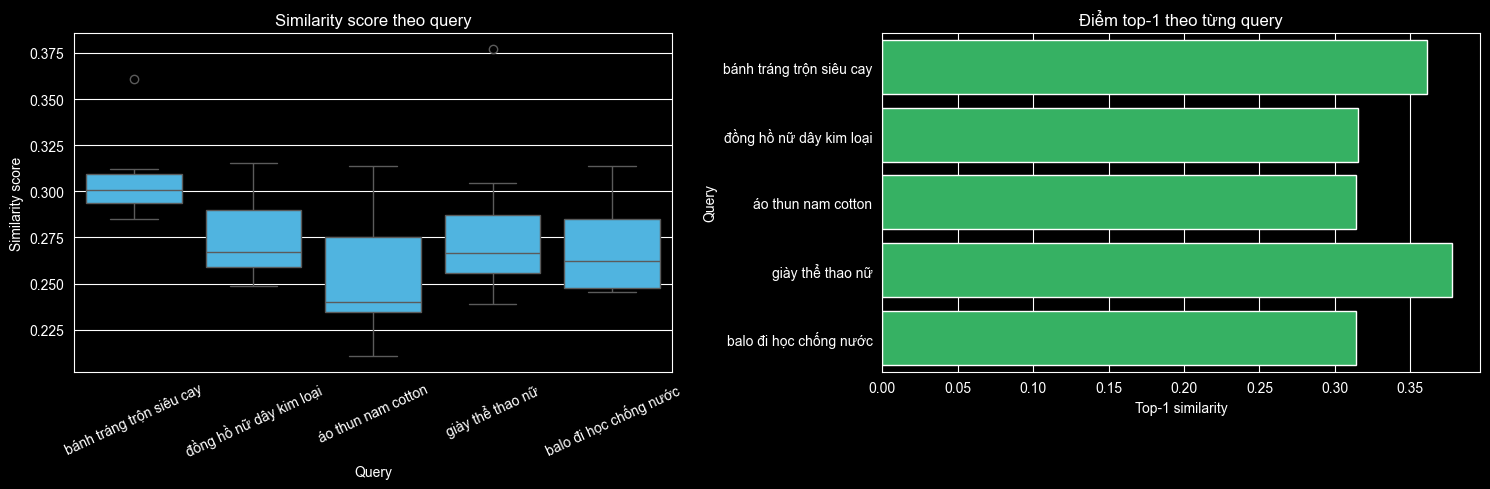

✅ Đã lưu biểu đồ: datas/processed/shopee_recommender_test_summary.png


In [7]:
# Visualize score và coverage của kết quả kiểm thử
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=shopee_test_df, x='query', y='similarity_score', ax=axes[0], color='#38bdf8')
axes[0].set_title('Similarity score theo query')
axes[0].set_xlabel('Query')
axes[0].set_ylabel('Similarity score')
axes[0].tick_params(axis='x', rotation=25)

top1 = shopee_test_df[shopee_test_df['rank'] == 1].copy()
sns.barplot(data=top1, x='similarity_score', y='query', ax=axes[1], color='#22c55e')
axes[1].set_title('Điểm top-1 theo từng query')
axes[1].set_xlabel('Top-1 similarity')
axes[1].set_ylabel('Query')

plt.tight_layout()
plt.savefig(processed_dir / 'shopee_recommender_test_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ: datas/processed/shopee_recommender_test_summary.png')


In [8]:
# Kiểm tra schema kết quả để đảm bảo API /api/recommend có thể serialize ổn định
expected_output_cols = {'product_id', 'name', 'similarity_score'}
missing_output_cols = expected_output_cols - set(shopee_test_df.columns)
assert not missing_output_cols, f'Thiếu cột kết quả bắt buộc: {missing_output_cols}'

api_preview = shopee_test_df.head(5).replace({pd.NA: None}).to_dict(orient='records')
print('Preview JSON-like output cho API:')
display(api_preview)
print('✅ Schema đầu ra recommender hợp lệ cho backend API')


Preview JSON-like output cho API:


[{'query': 'bánh tráng trộn siêu cay',
  'rank': 1,
  'product_id': 'shp_4938329028_272333943',
  'name': 'Bánh tráng hồng hạnh sate muối tắc',
  'location': '',
  'similarity_score': 0.3611,
  'url': 'https://shopee.vn/Bánh-tráng-hồng-hạnh-sate-muối-tắc-i.272333943.4938329028?sp_atk=d2300caf-1b99-41a6-a303-6682f6d1b6da&xptdk=d2300caf-1b99-41a6-a303-6682f6d1b6da'},
 {'query': 'bánh tráng trộn siêu cay',
  'rank': 2,
  'product_id': 'shp_4959124161_33410512',
  'name': 'BÁNH TRÁNG SATE TẮC MUỐI',
  'location': '',
  'similarity_score': 0.3123,
  'url': 'https://shopee.vn/BÁNH-TRÁNG-SATE-TẮC-MUỐI-i.33410512.4959124161?sp_atk=a322582a-7415-4d18-8ecc-1f0df11ac091&xptdk=a322582a-7415-4d18-8ecc-1f0df11ac091'},
 {'query': 'bánh tráng trộn siêu cay',
  'rank': 3,
  'product_id': 'shp_10079004677_171780566',
  'name': 'Bánh tráng trộn thập cẩm nhiều topping bánh tráng tự trộn kèm quất Ăn vặt nhà Cốm',
  'location': '',
  'similarity_score': 0.3081,
  'url': 'https://shopee.vn/Bánh-tráng-trộn-th

✅ Schema đầu ra recommender hợp lệ cho backend API
